In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manufacturing Quality Deviation Analysis System

This project simulates a manufacturing environment and detects abnormal production conditions using statistical anomaly detection techniques.

Goal: Identify production orders where parameters deviate significantly from normal operating conditions.

In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "order_id": range(1,1001),
    "temperature": np.random.normal(75,5,1000),
    "pressure": np.random.normal(30,3,1000),
    "cycle_time": np.random.normal(120,10,1000),
    "defect_rate": np.random.normal(2,0.5,1000)
})

data.head()

,order_id,temperature,pressure,cycle_time,defect_rate
0,1,77.483571,34.198066,113.248217,1.046096
1,2,74.308678,32.773901,118.554813,1.569807
2,3,78.238443,30.178891,112.075801,1.793197
3,4,82.615149,28.059190,116.920385,2.943844
4,5,73.829233,32.094670,101.063853,2.278277


In [3]:
data.to_csv("../dataset/manufacturing_data.csv", index=False)

## Exploratory Data Analysis

We examine the distribution of production parameters to understand normal operating ranges.|

In [4]:
data.describe()

,order_id,temperature,pressure,cycle_time,defect_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,75.096660,30.212509,120.058342,1.990640
std,288.819436,4.896080,2.992363,9.834543,0.513566
min,1.000000,58.793663,21.178834,89.804878,0.535276
25%,250.750000,71.762048,28.181275,113.520004,1.631290
50%,500.500000,75.126503,30.189231,119.997492,2.000092
75%,750.250000,78.239719,32.186647,126.609153,2.333473
max,1000.000000,94.263657,39.579323,159.262377,3.621546


## Anomaly Detection

We detect abnormal production conditions using Z-score based statistical deviation.

In [5]:
data["temp_zscore"] = (data["temperature"] - data["temperature"].mean()) / data["temperature"].std()

anomalies = data[abs(data["temp_zscore"]) > 2]

print("Number of detected anomalies:", len(anomalies))

Number of detected anomalies: 44


In [6]:
anomalies.head()

,order_id,temperature,pressure,cycle_time,defect_rate,temp_zscore
37,38,65.201649,25.606875,114.910364,2.085232,-2.021007
74,75,61.901274,32.988800,113.823481,1.633484,-2.695092
79,80,65.062155,32.550665,115.498107,1.875736,-2.049498
113,114,87.316211,31.487046,109.978125,1.395262,2.495783
125,126,85.952278,26.560964,125.471191,2.369827,2.217206


## Visualization of Production Temperature

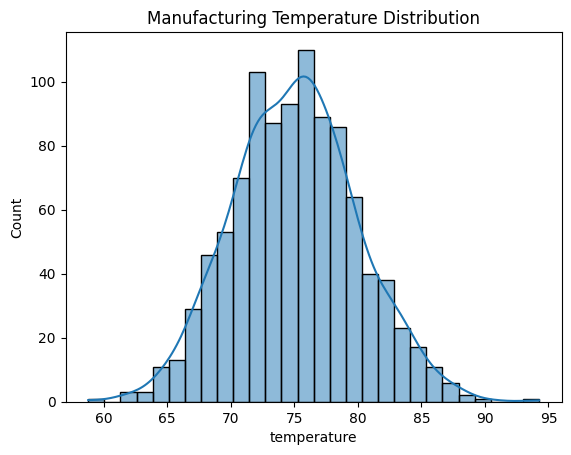

In [7]:
sns.histplot(data["temperature"], kde=True)
plt.title("Manufacturing Temperature Distribution")
plt.show()

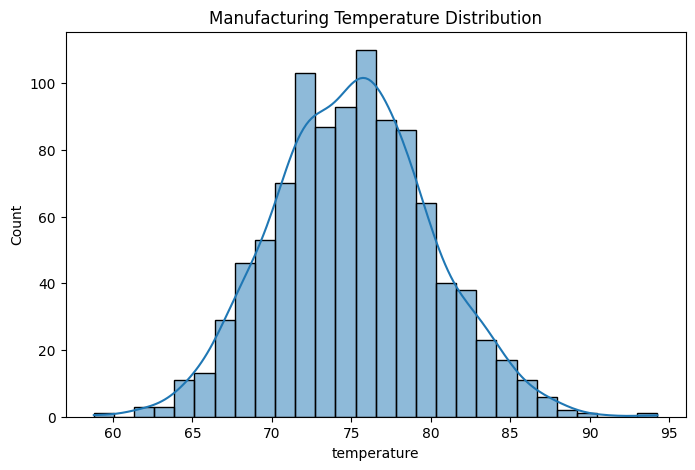

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data["temperature"], kde=True)
plt.title("Manufacturing Temperature Distribution")
plt.savefig("../outputs/temperature_distribution.png")

## Conclusion

The analysis detects abnormal production conditions by identifying statistical deviations in process parameters.  
This approach can help manufacturing teams monitor quality and flag potentially defective production orders early.